# Fase 4 - Front-end visual (KLT + pose relativa)

Entradas:  `results/MH_01_easy/fase1_sync.npz`, `results/MH_01_easy/fase2_calib.npz`
Salidas:   `results/MH_01_easy/fase4_vo.npz`

**Objetivo:** una odometría visual monocular funcionando: detectar, trackear,
estimar movimiento relativo, componer trayectoria.

**Criterio de éxito:** trayectoria VO cuya forma se parece a la GT tras
alineamiento **Sim(3)**, con ATE-RMSE (escala libre) < 2 m en los primeros 60 s.
La escala será arbitraria: es lo esperado, y es el asunto entero de la Fase 5.

**Dos criterios más, previos y más informativos**, que no están en el guion pero
que conviene exigir antes de mirar ninguna trayectoria:

- error de **rotación** relativa entre frames < ~0.3° de mediana,
- error de **dirección** de la traslación < ~10° de mediana en los frames con
  paralaje suficiente.

Los dos son **invariantes de escala**, así que se comparan directamente contra el
`T_rel_gt` que dejó la Fase 2 sin alinear nada. Si estos dos números están bien y
la trayectoria sale mal, el problema es la escala (Fase 5), no el front-end. Si
están mal, componer poses solo va a esconder dónde está el bug.

---

## 4.0 - La decisión que arrastramos de la Fase 2

Hay dos formas de tratar la distorsión y son **excluyentes**:

  (A) rectificar la imagen entera y trabajar con geometría pinhole pura,
  (B) trackear sobre la imagen CRUDA y rectificar solo los puntos detectados.

En la Fase 2 elegiste **(B)**, que es lo que hacen VINS-Mono y OpenVINS: rectificas
~250 puntos en vez de 360.000 píxeles, y no metes el suavizado de `remap` en el
KLT, que es justo lo que destroza la precisión subpíxel.

Esto tiene una consecuencia inmediata sobre el guion: `EurocSequence.image(k,
undistort=True)` de `anexo_utils` rectifica usando **`K` como matriz nueva**,
mientras que tu Fase 2 construyó `mapa_x`/`mapa_y` hacia **`K_new`**. Mezclar las
dos cosas — rectificar con los mapas de la Fase 2 y normalizar con `K` — es el
error del 22 % que ya cuantificaste en el test de aceptación de la Fase 2.

Aquí no se rectifica ninguna imagen. Se trackea en crudo y se normaliza con la
misma función de la Fase 2, con lo que `K_new` no vuelve a aparecer y la trampa
desaparece por construcción.

In [1]:
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

In [2]:
def encontrar_raiz(marcador="data"):
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / marcador).is_dir():
            return candidato
    raise FileNotFoundError(f"No encuentro '{marcador}/' hacia arriba desde {actual}")

In [3]:
RAIZ = encontrar_raiz()
ENTRADA_F1 = RAIZ / "results" / "MH_01_easy" / "fase1_sync.npz"
ENTRADA_F2 = RAIZ / "results" / "MH_01_easy" / "fase2_calib.npz"
SALIDA = RAIZ / "results" / "MH_01_easy" / "fase4_vo.npz"

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from scripts.anexo_utils import inv_T, make_T, Log, align_umeyama, ate_rmse   # noqa: E402

np.set_printoptions(precision=6, suppress=True)
print(f"OpenCV {cv2.__version__}")

OpenCV 5.0.0


In [4]:
d1 = np.load(ENTRADA_F1, allow_pickle=True)
d2 = np.load(ENTRADA_F2, allow_pickle=True)

K = d2["K"]
dist = d2["dist"]
T_imu_cam = d2["T_imu_cam"]          # lleva puntos de CÁMARA a IMU (anexo A.1)

# Los frames que tienen GT. t_cam_gt, T_world_cam y T_rel_gt comparten índice.
mask_gt = d1["mask_gt"]
rutas = d1["rutas_img"][mask_gt]
t_cam_gt = d2["t_cam_gt"]
T_world_cam = d2["T_world_cam"]      # pose GT de la CÁMARA en el mundo
T_rel_gt = d2["T_rel_gt"]            # T_c(i)_c(i+1): del frame i+1 al frame i
desp_rel = d2["desp_rel"]            # |traslación| entre frames, en METROS
ang_rel = d2["ang_rel"]
T_ARRANQUE = float(d1["t_arranque"])

assert len(rutas) == len(t_cam_gt) == len(T_world_cam), \
    "rutas, t_cam_gt y T_world_cam no están alineados: revisa mask_gt"
assert np.allclose(np.diff(t_cam_gt), np.diff(t_cam_gt)[0], atol=2e-3), \
    "t_cam_gt no es uniforme: los índices consecutivos no son frames consecutivos"

FU, FV, CU, CV = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
F_MEDIA = 0.5 * (FU + FV)
print(f"{len(rutas)} frames con GT, de {t_cam_gt[0]:.2f} a {t_cam_gt[-1]:.2f} s")
print(f"K: fu={FU:.2f} fv={FV:.2f} cu={CU:.2f} cv={CV:.2f}   dist={dist}")

3638 frames con GT, de 1.10 a 182.95 s
K: fu=458.65 fv=457.30 cu=367.21 cv=248.38   dist=[-0.283408  0.073959  0.000194  0.000018]


In [5]:
# Ventana de trabajo: se arranca en vuelo, no en el suelo. Durante el reposo
# inicial la traslación es cero y la matriz esencial es DEGENERADA: no es que dé
# error, es que devuelve una t que es ruido puro.
K0 = int(np.searchsorted(t_cam_gt, T_ARRANQUE))
N_FRAMES = 600                                    # 30 s a 20 Hz
K1 = min(K0 + N_FRAMES, len(rutas))

print(f"frames [{K0}, {K1})  ->  t = [{t_cam_gt[K0]:.2f}, {t_cam_gt[K1-1]:.2f}] s")
print(f"desplazamiento GT entre frames en esa ventana:")
print(f"  media = {desp_rel[K0:K1-1].mean()*100:.2f} cm   "
      f"max = {desp_rel[K0:K1-1].max()*100:.2f} cm   "
      f"min = {desp_rel[K0:K1-1].min()*100:.2f} cm")
print(f"  recorrido total = {desp_rel[K0:K1-1].sum():.2f} m")

frames [895, 1495)  ->  t = [45.85, 75.80] s
desplazamiento GT entre frames en esa ventana:
  media = 2.68 cm   max = 5.37 cm   min = 0.50 cm
  recorrido total = 16.08 m


Guarda ese `min`/`max`: el desplazamiento entre frames varía en un factor grande
a lo largo de la ventana. Volveremos a ello en 4.6, porque es la razón física de
que una VO monocular frame-a-frame no pueda dar una trayectoria con la forma
correcta ni siquiera en el mejor de los casos.

## 4.1 - Píxeles a coordenadas normalizadas

La misma función de la Fase 2: iteración de punto fijo sobre el modelo
Brown-Conrady, sin las 5 iteraciones fijas de `cv2.undistortPoints`. Aquí importa
más que allí, porque estas coordenadas entran directamente en la restricción
epipolar `x₁ᵀ E x₀ = 0`, que solo se cumple para normalizadas **ideales**.

In [6]:
def distorsionar(xy):
    """Brown-Conrady, fórmula cerrada. Normalizadas ideales -> normalizadas distorsionadas."""
    k1, k2, p1, p2 = dist
    x, y = xy[:, 0], xy[:, 1]
    r2 = x * x + y * y
    radial = 1.0 + k1 * r2 + k2 * r2 * r2
    dx_tan = 2.0 * p1 * x * y + p2 * (r2 + 2.0 * x * x)
    dy_tan = p1 * (r2 + 2.0 * y * y) + 2.0 * p2 * x * y
    return np.column_stack([x * radial + dx_tan, y * radial + dy_tan])

In [7]:
def pixeles_a_normalizadas(uv, max_iter=100, tol=1e-14):
    """(N,2) píxeles distorsionados -> (N,2) normalizadas ideales."""
    k1, k2, p1, p2 = dist
    uv = np.asarray(uv, dtype=np.float64).reshape(-1, 2)
    xd = (uv[:, 0] - CU) / FU
    yd = (uv[:, 1] - CV) / FV
    x, y = xd.copy(), yd.copy()
    for _ in range(max_iter):
        r2 = x * x + y * y
        radial = 1.0 + k1 * r2 + k2 * r2 * r2
        dx_tan = 2.0 * p1 * x * y + p2 * (r2 + 2.0 * x * x)
        dy_tan = p1 * (r2 + 2.0 * y * y) + 2.0 * p2 * x * y
        x_nuevo = (xd - dx_tan) / radial
        y_nuevo = (yd - dy_tan) / radial
        cambio = np.max(np.abs(x_nuevo - x) + np.abs(y_nuevo - y))
        x, y = x_nuevo, y_nuevo
        if cambio < tol:
            break
    return np.column_stack([x, y])

In [8]:
def normalizadas_a_pixeles(xy):
    xy_d = distorsionar(np.asarray(xy, dtype=np.float64).reshape(-1, 2))
    return np.column_stack([FU * xy_d[:, 0] + CU, FV * xy_d[:, 1] + CV])

In [9]:
# Ida y vuelta sobre una rejilla que cubre toda la imagen (mismo test que en Fase 2).
uu, vv = np.meshgrid(np.linspace(0, 751, 40), np.linspace(0, 479, 30))
rejilla = np.column_stack([uu.ravel(), vv.ravel()])
err_rt = np.linalg.norm(normalizadas_a_pixeles(pixeles_a_normalizadas(rejilla)) - rejilla, axis=1)

norm_cv = cv2.undistortPoints(rejilla.reshape(-1, 1, 2), K, dist).reshape(-1, 2)
err_cv = np.linalg.norm(normalizadas_a_pixeles(norm_cv) - rejilla, axis=1)

print(f"ida y vuelta, solver iterativo : medio {err_rt.mean():.2e} px   max {err_rt.max():.2e} px")
print(f"ida y vuelta, cv2.undistortPoints: medio {err_cv.mean():.2e} px   max {err_cv.max():.2e} px")
assert err_rt.max() < 1e-9, "el roundtrip falla: revisa K o dist"

ida y vuelta, solver iterativo : medio 6.94e-14 px   max 7.46e-13 px
ida y vuelta, cv2.undistortPoints: medio 5.72e-02 px   max 2.91e-01 px


## 4.2 - El tracker KLT con IDs persistentes

La diferencia entre "sé hacer KLT" y "tengo un front-end de VIO" son los **IDs
persistentes**: el MSCKF de la Fase 6A necesita saber que la feature #4237 se vio
en los frames 100..118 para poder triangularla y marginalizarla. Se escribe con
IDs desde el principio porque añadirlos después obliga a reescribir el bucle.

Respecto al `KLTTracker` del guion, aquí van tres cambios que hacen falta para que
no reviente en ejecución larga:

- **guarda si se queda sin puntos**: `calcOpticalFlowPyrLK` con 0 puntos lanza
  excepción, y eso pasa en cuanto hay un frame movido;
- **`cv2.circle` con enteros de Python**, no con `np.int64`, que algunas builds de
  OpenCV rechazan;
- **`float32` explícito** al reasignar los puntos supervivientes, porque el
  indexado booleano puede devolver `float64` y KLT exige `CV_32F`.

In [10]:
class RastreadorKLT:
    """KLT piramidal con IDs persistentes, forwarrd-backward check y redetección enmascarada."""
    
    def __init__(self, max_feats=250, min_feats=150, calidad=0.01, dist_min=18,
                 ventana=(21, 21), niveles=3, umbral_fb=1.0):
        self.max_feats, self.min_feats = max_feats, min_feats
        self.calidad, self.dist_min = calidad, dist_min
        self.umbral_fb = umbral_fb
        self.lk = dict(winSize=ventana, maxLevel=niveles,
                       criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
        self.img_prev = None
        self.pts = np.zeros((0, 2), np.float32)
        self.ids = np.zeros((0,), np.int64)
        self._sig_id = 0
        self.tracks = defaultdict(list)          # id -> [(k, u, v), ...]
        
    def _detectar(self, img):
        n_nuevas = self.max_feats - len(self.pts)
        if n_nuevas <= 0:
            return
        # La máscara evita que goodFeaturesToTrack devuelva las esquinas que ya
        # estoy trackeando: sin ella acabas con features duplicadas y la esencial
        # mal condicionada.
        mascara = np.full(img.shape, 255, np.uint8)
        for p in self.pts:
            cv2.circle(mascara, (int(round(float(p[0]))), int(round(float(p[1])))),
                       self.dist_min, 0, -1)
        nuevas = cv2.goodFeaturesToTrack(img, n_nuevas, self.calidad, self.dist_min,
                                         mask=mascara, blockSize=7)
        if nuevas is None:
            return
        nuevas = nuevas.reshape(-1, 2).astype(np.float32)
        ids = np.arange(self._sig_id, self._sig_id + len(nuevas), dtype=np.int64)
        self._sig_id += len(nuevas)
        self.pts = np.vstack([self.pts, nuevas]).astype(np.float32)
        self.ids = np.concatenate([self.ids, ids])
        
    def _anotar(self, k):
        for i, p in zip(self.ids, self.pts):
            self.tracks[int(i)].append((k, float(p[0]), float(p[1])))

    def rastrear(self, img, k):
        """Devuelve (ids, pts_prev, pts_cur) de las features SUPERVIVIENTES."""
        if self.img_prev is None or len(self.pts) == 0:
            self.img_prev = img
            self._detectar(img)
            self._anotar(k)
            return self.ids.copy(), None, self.pts.copy()

        pts_prev = self.pts.reshape(-1, 1, 2)
        cur, st, _ = cv2.calcOpticalFlowPyrLK(self.img_prev, img, pts_prev, None, **self.lk)
        # Forward-backward: se trackea de vuelta y se exige volver al punto de
        # partida. Es el filtro de outliers más eficaz del KLT, y elimina los
        # tracks que se "enganchan" a un borde distinto.
        atras, st2, _ = cv2.calcOpticalFlowPyrLK(img, self.img_prev, cur, None, **self.lk)
        fb = np.linalg.norm(pts_prev - atras, axis=2).ravel()

        h, w = img.shape
        c = cur.reshape(-1, 2)
        ok = (st.ravel() == 1) & (st2.ravel() == 1) & (fb < self.umbral_fb)
        # KLT devuelve status=1 para puntos con medio parche fuera de la imagen.
        ok &= (c[:, 0] > 3) & (c[:, 0] < w - 4) & (c[:, 1] > 3) & (c[:, 1] < h - 4)

        ids_ok = self.ids[ok]
        prev_ok = self.pts[ok].astype(np.float32)
        cur_ok = c[ok].astype(np.float32)

        self.pts, self.ids, self.img_prev = cur_ok, ids_ok, img
        if len(self.pts) < self.min_feats:
            self._detectar(img)
        self._anotar(k)
        return ids_ok, prev_ok, cur_ok

In [11]:
def leer(k):
    """Imagen CRUDA (sin rectificar) del frame k del índice con GT."""
    img = cv2.imread(str(rutas[k]), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(rutas[k])
    return img

### Diagnóstico del tracker

Esto va **antes** de estimar ninguna pose. Un tracker malo produce poses malas de
una forma que, vista desde la trayectoria, es indistinguible de un bug de
convenios.

In [12]:
tr_diag = RastreadorKLT()
n_feats, flujos = [], []
for k in range(K0, min(K0 + 400, K1)):
    ids, p_prev, p_cur = tr_diag.rastrear(leer(k), k)
    n_feats.append(len(p_cur))
    if p_prev is not None and len(p_prev):
        flujos.append(np.median(np.linalg.norm(p_cur - p_prev, axis=1)))

longitudes = np.array([len(v) for v in tr_diag.tracks.values()])
print(f"features por frame : media {np.mean(n_feats):.0f}   min {np.min(n_feats)}")
print(f"flujo mediano      : {np.median(flujos):.2f} px/frame   p95 {np.percentile(flujos, 95):.2f}")
print(f"longitud de track  : mediana {np.median(longitudes):.0f}   "
      f"p90 {np.percentile(longitudes, 90):.0f}   max {longitudes.max()}")
print(f"tracks totales     : {len(longitudes)}")

features por frame : media 192   min 146
flujo mediano      : 3.20 px/frame   p95 9.28
longitud de track  : mediana 34   p90 143   max 400
tracks totales     : 1369


**Valores sanos en MH_01**: 200–250 features/frame, flujo mediano 3–8 px/frame,
longitud de track mediana 8–20 frames.

Cómo leer las desviaciones:

- flujo mediano > 25 px/frame → sube `niveles` (la pirámide no alcanza),
- longitud mediana de 2–3 frames → el forward-backward está mal, o `dist_min` es
  tan pequeño que estás detectando ruido,
- features/frame pegado a `min_feats` → estás redetectando cada frame, y eso
  significa que los tracks mueren; mira el flujo antes de subir `max_feats`.

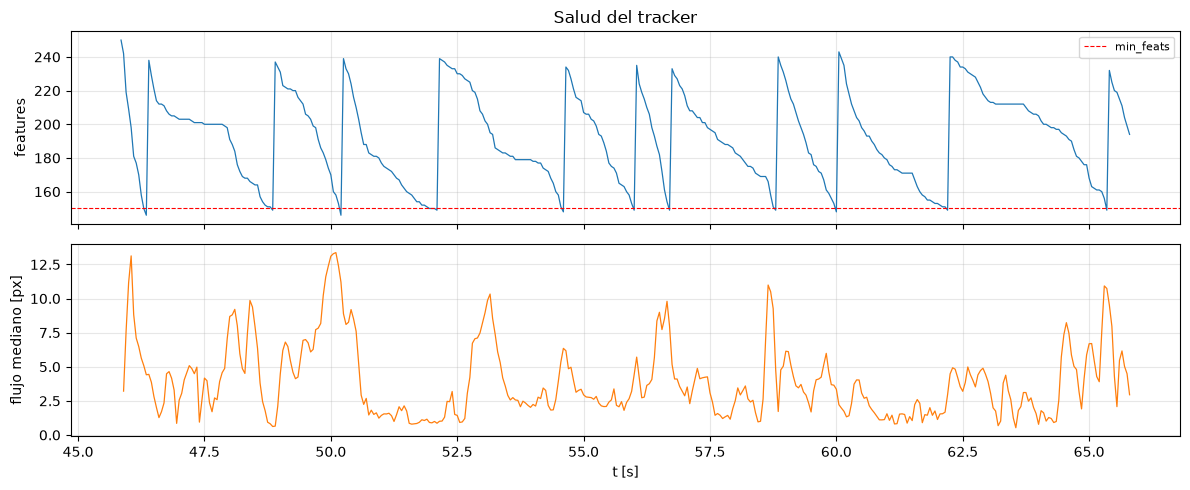

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_cam_gt[K0:K0 + len(n_feats)], n_feats, lw=0.9)
axes[0].axhline(tr_diag.min_feats, color="r", ls="--", lw=0.8, label="min_feats")
axes[0].set_ylabel("features"); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[0].set_title("Salud del tracker")
axes[1].plot(t_cam_gt[K0 + 1:K0 + 1 + len(flujos)], flujos, lw=0.9, c="C1")
axes[1].set_ylabel("flujo mediano [px]"); axes[1].set_xlabel("t [s]"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

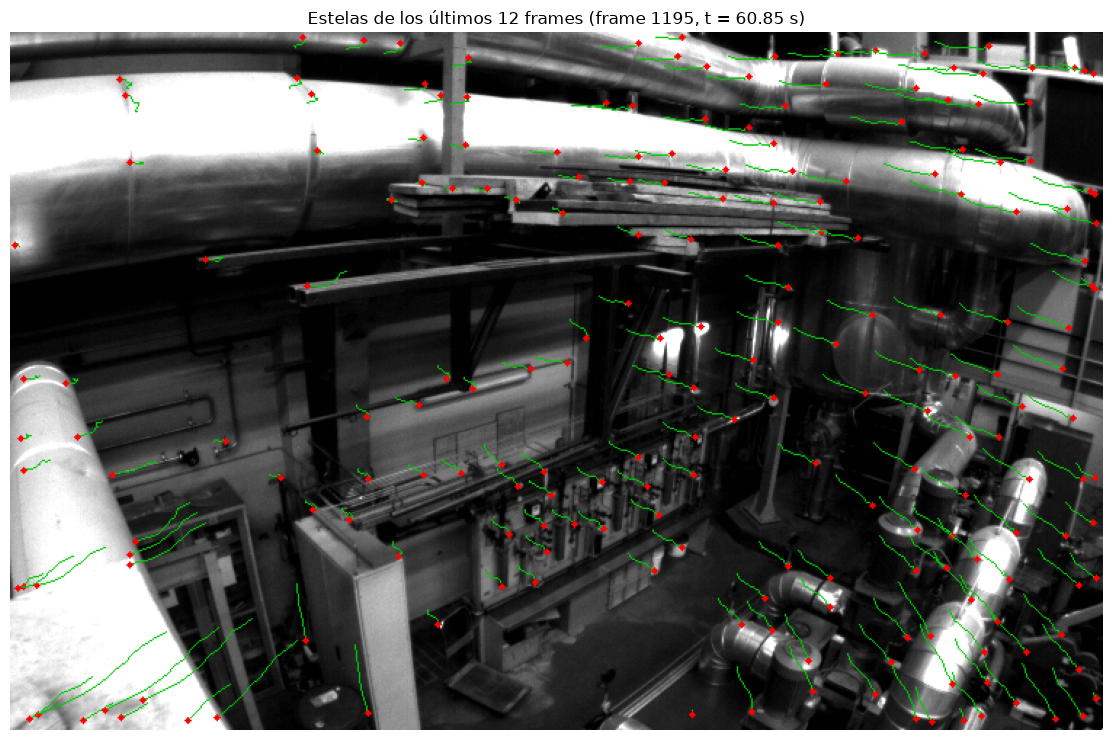

In [14]:
# Estelas de los tracks sobre la imagen, que es como se ve de verdad si algo va mal.
k_vis = K0 + 300
img_vis = cv2.cvtColor(leer(k_vis), cv2.COLOR_GRAY2BGR)
for i, hist in tr_diag.tracks.items():
    cola = [(u, v) for (kk, u, v) in hist if k_vis - 12 <= kk <= k_vis]
    if len(cola) < 2:
        continue
    for a, b in zip(cola[:-1], cola[1:]):
        cv2.line(img_vis, (int(a[0]), int(a[1])), (int(b[0]), int(b[1])), (0, 200, 0), 1)
    cv2.circle(img_vis, (int(cola[-1][0]), int(cola[-1][1])), 2, (0, 0, 255), -1)

plt.figure(figsize=(12, 7.5))
plt.imshow(img_vis[:, :, ::-1])
plt.title(f"Estelas de los últimos 12 frames (frame {k_vis}, t = {t_cam_gt[k_vis]:.2f} s)")
plt.axis("off"); plt.tight_layout(); plt.show()

Las estelas deben ser suaves y **coherentes entre sí**: en una traslación pura
apuntan todas hacia (o desde) un mismo punto de fuga, y en una rotación pura son
casi paralelas. Estelas cruzándose en direcciones incompatibles son outliers que
el forward-backward no ha cazado, y son los que van a envenenar la esencial.

## 4.2b - Validación visual continua del tracker

Las métricas anteriores resumen estadísticamente el comportamiento del KLT, pero
pueden esconder problemas locales. Antes de utilizar las correspondencias para
estimar la matriz esencial, vamos a inspeccionar el tracker durante toda la
secuencia.

Generaremos cuatro vídeos:

1. **Vídeo original**: referencia de lo que realmente ve la cámara.
2. **Features activas**: posición de todas las features que el tracker mantiene
   en cada frame.
3. **Tracks / estelas**: historia de cada feature mientras permanece activa.
4. **Tracks + HUD**: el mismo vídeo anterior, añadiendo métricas instantáneas del
   tracker.

Esto todavía NO estima movimiento de la cámara ni utiliza `findEssentialMat` o
`recoverPose`. Solo estamos validando:

    imagen -> detección -> KLT -> IDs persistentes

La idea es comprobar visualmente que los datos que entregaremos a la geometría
de la sección 4.3 son coherentes.

In [15]:
# %% 4.2b - Configuración de los vídeos

from tqdm.auto import tqdm

VIDEO_DIR = SALIDA.parent / "fase4_videos"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

# Comprobar si existen los videos para no regenerar
FORZAR_VIDEO = False

# Toda la secuencia de cámara que tiene GT asociado.
#
# Si primero quieres probar solo nuestros 30 s de trabajo:
#
# VIDEO_K0 = K0
# VIDEO_K1 = K1
#
VIDEO_K0 = 0
VIDEO_K1 = len(rutas)

# Frecuencia real de la cámara obtenida de lso timestamps.
FPS_VIDEO = float(1.0 / np.median(np.diff(t_cam_gt[VIDEO_K0:VIDEO_K1])))

# En el vídeo de estelas:
#
# None -> dibujar TODA la vida de la feature mientras siga activa.
# 60   -> dibujar solo sus últimos 60 frames (~3 s).
#
MAX_HIST_ESTELA = None

img0 = leer(VIDEO_K0)
H_VIDEO, W_VIDEO = img0.shape

print(f"Frames       : [{VIDEO_K0}, {VIDEO_K1}) -> {VIDEO_K1 - VIDEO_K0}")
print(f"Tiempo       : {t_cam_gt[VIDEO_K0]:.2f} -> {t_cam_gt[VIDEO_K1-1]:.2f} s")
print(f"FPS          : {FPS_VIDEO:.2f}")
print(f"Resolución   : {W_VIDEO} x {H_VIDEO}")
print(f"Salida       : {VIDEO_DIR}")

Frames       : [0, 3638) -> 3638
Tiempo       : 1.10 -> 182.95 s
FPS          : 20.00
Resolución   : 752 x 480
Salida       : C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase4_videos


c:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
def crear_video(nombre):
    """Crea un VideoWriter MP4 con la resolución de las imágenes EuRoC."""
    path = VIDEO_DIR / nombre

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    writer = cv2.VideoWriter(
        str(path),
        fourcc,
        FPS_VIDEO,
        (W_VIDEO, H_VIDEO),
        True,
    )

    if not writer.isOpened():
        raise RuntimeError(f"No se pudo abrir VideoWriter para {path}")

    return writer, path


def gris_a_bgr(img):
    """VideoWriter espera una imagen de 3 canales."""
    return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


def falta_video(nombre, min_mb=0.1):
    """True si hay que generar. Un fichero por debajo de min_mb se considera roto."""
    ruta = VIDEO_DIR / nombre
    if FORZAR_VIDEO or not ruta.is_file() or ruta.stat().st_size < min_mb * 1e6:
        return True
    print(f"ya existe, se omite: {ruta}  ({ruta.stat().st_size / 1e6:.1f} MB)")
    return False

### Vídeo 1 - Secuencia original

Primero generamos una referencia sin ningún tipo de anotación.

Este vídeo permite identificar visualmente:

- tramos con movimiento rápido,
- motion blur,
- cambios de iluminación,
- zonas con poca textura,
- escenas cercanas o lejanas,
- periodos con poca traslación.

Después podremos comparar directamente esos momentos con el comportamiento del
tracker en los siguientes vídeos.

In [17]:
# %% Vídeo 1 - Cámara original

if falta_video("01_original.mp4"):

    writer_raw, path_raw = crear_video("01_original.mp4")

    try:
        for k in tqdm(range(VIDEO_K0, VIDEO_K1), desc="Vídeo original"):
            img = leer(k)
            
            # La imagen EuRoC es monocroma.
            # VideoWriter trabaja aquí con tres canales BGR.
            frame = gris_a_bgr(img)
            
            writer_raw.write(frame)
        
    finally:
        writer_raw.release()

    print(f"Guardado: {path_raw}")

ya existe, se omite: C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase4_videos\01_original.mp4  (84.0 MB)


### Vídeo 2 - Features activas

Ahora ejecutamos el mismo `RastreadorKLT` utilizado en la validación anterior y
dibujamos todas las features que permanecen activas después de procesar cada frame.

Es importante distinguir:

    p_cur
        features que han sobrevivido desde el frame anterior

    tracker.pts
        todas las features activas DESPUÉS de la posible redetección

Para este vídeo queremos `tracker.pts`, porque queremos visualizar el conjunto
real de features que queda disponible para procesar el siguiente frame.

Una distribución sana debería mostrar:

- puntos repartidos por buena parte de la imagen,
- desaparición gradual de features,
- aparición de nuevas features cuando se alcanza `min_feats`,
- ausencia de parpadeos masivos o saltos inexplicables.

### Vídeo 3 - Tracks persistentes y estelas

Además de saber dónde está actualmente cada feature, queremos ver de dónde viene.

Para cada ID activo utilizamos:

    tracker.tracks[id]

que contiene:

    [(frame_0, u_0, v_0),
     (frame_1, u_1, v_1),
     ...
     (frame_actual, u, v)]

Mientras una feature siga activa dibujaremos toda su trayectoria sobre la imagen.

Cuando el tracker pierda esa feature, su ID dejará de estar en `tracker.ids` y su
estela desaparecerá del vídeo.

Por tanto, visualmente podremos observar el ciclo completo:

    detección
       ↓
    seguimiento
       ↓
    desplazamiento durante varios frames
       ↓
    pérdida / salida de imagen

Las estelas deberían ser suaves. Saltos abruptos, zig-zags o movimientos
incompatibles con las features vecinas pueden indicar falsos tracks.

### Vídeo 4 - Tracks + telemetría del tracker

El último vídeo añade métricas instantáneas para relacionar lo que vemos con el
estado interno del KLT.

Mostraremos:

- frame e instante temporal,
- número de features activas,
- features supervivientes,
- features nuevas,
- features perdidas,
- flujo mediano del frame,
- edad mediana de los tracks activos.

Esto permite, por ejemplo, ver un movimiento brusco y comprobar inmediatamente si
provoca:

    aumento del flujo
        ↓
    pérdida de tracks
        ↓
    redetección de nuevas features

In [18]:
# %% Vídeos 2, 3 y 4 - Un único recorrido del tracker

if not any([falta_video("02_features.mp4"),
            falta_video("03_tracks.mp4"),
            falta_video("04_tracks_hud.mp4")]):
    print("Los tres vídeos ya existen. Pon FORZAR_VIDEOS = True para regenerarlos.")

else:
    writer_feats, path_feats = crear_video("02_features.mp4")
    writer_tracks, path_tracks = crear_video("03_tracks.mp4")
    writer_hud, path_hud = crear_video("04_tracks_hud.mp4")

    # IMPORTANTE:
    # usamos un tracker NUEVO porque queremos procesar la secuencia desde VIDEO_K0 de forma cronológica.
    tr_video = RastreadorKLT()

    n_activos_anterior = 0

    try:
        for k in tqdm(range(VIDEO_K0, VIDEO_K1), desc="Tracker + vídeos"):
            
            # -------------------------------------------------------------
            # 1. Leer imagen y ejecutar KLT
            # -------------------------------------------------------------
            img = leer(k)
            
            ids_ok, p_prev, p_cur = tr_video.rastrear(img, k)
            
            # Después de rastrear:
            #
            # ids_ok / p_cur
            #     = features que sobrevivieron desde el frame anterior
            #
            # tr_video.ids / tr_video.pts
            #     = supervivientes + nuevas features redetectadas
            #
            ids_activos = tr_video.ids
            pts_activos = tr_video.pts
            
            n_activos = len(ids_activos)
            
            # -------------------------------------------------------------
            # 2. Métricas instantáneas
            # -------------------------------------------------------------
            if p_prev is None:
                # Primer frame: todas las features son nuevas.
                n_supervivientes = 0
                n_perdidas = 0
                n_nuevas = n_activos
                flujo_mediano = np.nan
                
            else:
                n_supervivientes = len(ids_ok)
                
                # Las que estaban activas antes pero no sobrevivieron.
                n_perdidas = max(0, n_activos_anterior - n_supervivientes)
                
                # Después de eliminar las perdidas, _detectar() puede añadir nuevas.
                n_nuevas = max(0, n_activos - n_supervivientes)
                
                if len(p_cur):
                    flujo_mediano = float(np.median(np.linalg.norm(p_cur - p_prev, axis=1)))
                else:
                    flujo_mediano = np.nan
                
            # Edad de los tracks que siguen vivos.
            edades = [len(tr_video.tracks[int(fid)]) for fid in ids_activos]
            
            edad_mediana = (float(np.median(edades)) if edades else 0.0)
            
            
            # =============================================================
            # VÍDEO 2: FEATURES ACTIVAS
            # =============================================================
            frame_feats = gris_a_bgr(img)
            
            for p in pts_activos:
                u = int(round(float(p[0])))
                v = int(round(float(p[1])))
                
                cv2.circle(frame_feats, (u, v), 2, (0, 0, 255), -1)
                
                writer_feats.write(frame_feats)
            
            
            # =============================================================
            # VÍDEO 3: ESTELAS DE FEATURES ACTIVAS
            # =============================================================
            frame_tracks = gris_a_bgr(img)
            
            for fid in ids_activos:
                
                hist = tr_video.tracks[int(fid)]
                
                # Opcionalmente limitar la longitud visual de la estela.
                if MAX_HIST_ESTELA is not None:
                    hist = hist[-MAX_HIST_ESTELA:]
                
                puntos = [(int(round(u)), int(round(v))) for _, u, v in hist]
                
                # Dibujar la trayectoria.
                if len(puntos) >= 2:
                    for a, b in zip(puntos[:-1], puntos[1:]):
                        cv2.line(frame_tracks, a, b, (0, 255, 0), 1)
                
                # posición acutal de la feature.
                if puntos:
                    cv2.circle(frame_tracks, puntos[-1], 2, (0, 0, 255), -1)
                
            writer_tracks.write(frame_tracks)
            
            
            # =============================================================
            # VÍDEO 4: ESTELAS + HUD
            # =============================================================
            # Empezamos exactamente con la visualización anterior.
            frame_hud = frame_tracks.copy()
            
            # Fondo oscuro para hacer legible el texto.
            cv2.rectangle(frame_hud, (8, 8), (430, 165), (0, 0, 0), -1)
            
            if np.isnan(flujo_mediano):
                flujo_txt = "---"
            else:
                flujo_txt = f"{flujo_mediano:.2f} px"
            
            lineas = [
                f"frame: {k}",
                f"t: {t_cam_gt[k]:.2f} s",
                f"features activas: {n_activos}",
                f"supervivientes: {n_supervivientes}",
                f"nuevas / perdidas: {n_nuevas} / {n_perdidas}",
                f"flujo mediano: {flujo_txt}",
                f"edad mediana track: {edad_mediana:.0f} frames",
            ]
            
            y = 30
            
            for texto in lineas:
                cv2.putText(frame_hud, texto, (18, y), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (255, 255, 255), 1, cv2.LINE_AA,)
                y += 19
            
            writer_hud.write(frame_hud)
            
            # Estado necesario para calcular pérdidas en el frame siguiente.
            n_activos_anterior = n_activos
                

    finally:
        writer_feats.release()
        writer_tracks.release()
        writer_hud.release()
        
    print("Vídeos guardados:")
    print(f"  {path_feats}")
    print(f"  {path_tracks}")
    print(f"  {path_hud}")

ya existe, se omite: C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase4_videos\02_features.mp4  (3795.6 MB)
ya existe, se omite: C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase4_videos\03_tracks.mp4  (328.9 MB)
ya existe, se omite: C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase4_videos\04_tracks_hud.mp4  (322.6 MB)
Los tres vídeos ya existen. Pon FORZAR_VIDEOS = True para regenerarlos.


## 4.3 - La pose relativa

Con puntos en coordenadas normalizadas la matriz esencial se estima con `K = I`, y
el umbral de RANSAC **deja de estar en píxeles**: hay que dividirlo por la focal.
Pasar 1.0 como umbral con puntos normalizados significa "acepto reproyecciones de
458 píxeles", o sea todo inlier. Es una de las trampas de 4.8 y no da ningún
error, solo una E basura.

Tres cosas que hay que tener presentes del resultado de `recoverPose`:

- devuelve `R, t` tales que **`p_c1 = R·p_c0 + t`**, es decir `T_c1_c0`. Para
  componer la trayectoria hace falta la inversa;
- `|t| = 1` **siempre**. No es que la escala esté mal estimada: es que no está
  estimada en absoluto;
- ya aplica el test de cheiralidad (puntos delante de ambas cámaras), que es lo
  que desambigua entre las cuatro soluciones de la descomposición de E.

In [19]:
METODO = cv2.USAC_MAGSAC if hasattr(cv2, "USAC_MAGSAC") else cv2.RANSAC
print("método de RANSAC:", "USAC_MAGSAC" if METODO != cv2.RANSAC else "RANSAC (fallback)")


def pose_relativa(n0, n1, umbral_px=1.0, prob=0.999):
    """
    n0, n1: (N,2) coordenadas NORMALIZADAS ideales de dos frames.
    Devuelve (T_c1_c0, inliers) o (None, None) si no hay solución fiable.
    """
    if len(n0) < 8:
        return None, None
    n0 = np.ascontiguousarray(n0, dtype=np.float64)
    n1 = np.ascontiguousarray(n1, dtype=np.float64)

    # El umbral va en unidades normalizadas: píxeles / focal.
    thr = umbral_px / F_MEDIA

    E, mask = cv2.findEssentialMat(n0, n1, np.eye(3), method=METODO,
                                   prob=prob, threshold=thr)
    if E is None or E.shape[0] < 3:
        return None, None
    E = E[:3]                       # con RANSAC siempre es 3x3; por si acaso

    n_in, R, t, mask_pose = cv2.recoverPose(E, n0, n1, np.eye(3), mask=mask.copy())
    if n_in < 10:
        return None, None
    return make_T(R, t.ravel()), (mask_pose.ravel() > 0)

método de RANSAC: USAC_MAGSAC


### Degeneración: el flujo no es paralaje

El guion propone detectar la degeneración con el desplazamiento mediano en
píxeles. Funciona como pre-filtro barato, pero es conceptualmente flojo: **una
rotación pura produce muchísimo flujo y cero paralaje**. Un dron que gira sobre sí
mismo pasa ese test con nota y la esencial es completamente degenerada.

El criterio correcto es el **paralaje derrotado**: compensar la rotación y mirar
qué desplazamiento queda. Un punto en el infinito visto desde `c0` en dirección
`d0 = [n0, 1]` se ve desde `c1` en dirección `R·d0`, **independientemente de la
traslación**. Lo que sobra de ahí es traslación observable.

Es exactamente lo que hace VINS-Mono, solo que él derrota con el giróscopo (lo
tienes de la Fase 3) en vez de con la R estimada. Aquí uso la R estimada, que es
gratis y sirve como comprobación a posteriori.

In [20]:
def paralaje_derotada(n0, n1, R):
    """Residuo en PÍXELES tras compensar la rotación R (= R_c1_c0). Mide traslación."""
    d0 = np.hstack([n0, np.ones((len(n0), 1))])
    v = d0 @ R.T                       # (R @ d0.T).T
    pred = v[:, :2] / v[:, 2:3]        # dónde caería si solo hubiera rotación
    return np.linalg.norm(n1 - pred, axis=1) * F_MEDIA

## 4.4 - Validar el front-end SIN componer nada

Este es el paso que el guion no incluye y que ahorra la mayor parte del tiempo de
depuración. La Fase 2 dejó `T_rel_gt[i] = T_c(i)_c(i+1)`: la pose relativa
verdadera entre frames consecutivos. Se puede comparar directamente con la
estimada, **sin alinear trayectorias y sin conocer la escala**, en dos métricas:

- **rotación**: `|Log(R_gt^T · R_est)|`, en grados. No depende de la escala.
- **dirección de la traslación**: ángulo entre `t_gt/|t_gt|` y `t_est/|t_est|`.
  Tampoco depende de la escala, porque solo compara direcciones.

Atención al sentido: `recoverPose` da `T_c1_c0` y `T_rel_gt` es `T_c0_c1`. Hay que
invertir uno de los dos. Comparar sin invertir da un error de rotación que parece
"casi bien" en tramos lentos, que es la peor forma posible de equivocarse.

In [21]:
tr = RastreadorKLT()
n_frames = K1 - K0

reg_rot, reg_dir, reg_par, reg_inl, reg_n, reg_flujo = [], [], [], [], [], []
rel_est = []            # T_c(i)_c(i+1) estimada, para reutilizar en 4.5
ids_prev = None

for k in range(K0, K1):
    ids, p_prev, p_cur = tr.rastrear(leer(k), k)
    if p_prev is None or len(p_prev) < 20:
        rel_est.append(None)
        continue

    n0 = pixeles_a_normalizadas(p_prev)
    n1 = pixeles_a_normalizadas(p_cur)
    T_c1c0, inl = pose_relativa(n0, n1)
    if T_c1c0 is None:
        rel_est.append(None)
        continue

    T_c0c1 = inv_T(T_c1c0)                       # mismo sentido que T_rel_gt
    rel_est.append(T_c0c1)

    i = k - 1                                    # T_rel_gt[i] va del frame i+1 al i
    R_err = T_rel_gt[i][:3, :3].T @ T_c0c1[:3, :3]
    reg_rot.append(np.degrees(np.linalg.norm(Log(R_err))))

    t_gt = T_rel_gt[i][:3, 3]
    t_es = T_c0c1[:3, 3]
    coseno = (t_gt @ t_es) / (np.linalg.norm(t_gt) * np.linalg.norm(t_es) + 1e-12)
    reg_dir.append(np.degrees(np.arccos(np.clip(coseno, -1, 1))))

    reg_par.append(np.median(paralaje_derotada(n0, n1, T_c1c0[:3, :3])))
    reg_inl.append(inl.mean())
    reg_n.append(len(n0))
    reg_flujo.append(np.median(np.linalg.norm(p_cur - p_prev, axis=1)))

reg_rot = np.array(reg_rot); reg_dir = np.array(reg_dir); reg_par = np.array(reg_par)
reg_inl = np.array(reg_inl); reg_n = np.array(reg_n); reg_flujo = np.array(reg_flujo)
print(f"{len(reg_rot)} de {n_frames} frames con pose estimada")

144 de 600 frames con pose estimada


In [22]:
print(f"error de ROTACIÓN relativa [°] : mediana {np.median(reg_rot):.3f}   "
      f"p90 {np.percentile(reg_rot, 90):.3f}   max {reg_rot.max():.3f}")
print(f"error de DIRECCIÓN de t [°]    : mediana {np.median(reg_dir):.2f}   "
      f"p90 {np.percentile(reg_dir, 90):.2f}   max {reg_dir.max():.2f}")
print(f"paralaje derrotada [px]        : mediana {np.median(reg_par):.2f}   "
      f"p10 {np.percentile(reg_par, 10):.2f}")
print(f"ratio de inliers               : mediana {np.median(reg_inl):.3f}")

assert np.median(reg_rot) < 1.0, \
    "el error de rotación relativa es demasiado alto: el problema está en el tracker " \
    "o en la normalización, no en la composición de poses"

error de ROTACIÓN relativa [°] : mediana 0.023   p90 0.093   max 0.208
error de DIRECCIÓN de t [°]    : mediana 2.44   p90 6.31   max 52.83
paralaje derrotada [px]        : mediana 2.26   p10 1.53
ratio de inliers               : mediana 0.090


La rotación es la parte fácil: sale bien incluso con poco paralaje, porque la
homografía inducida por la rotación está sobredeterminada por cientos de puntos.
La dirección de la traslación es la parte frágil, y su error **depende del
paralaje**. La gráfica siguiente lo hace explícito.

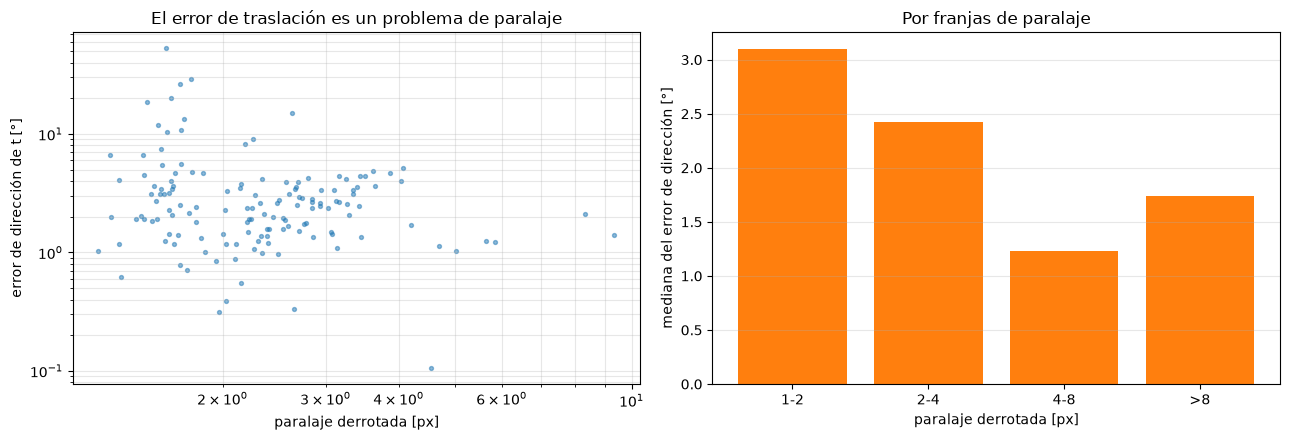

  paralaje   <0.5 px -> error de dirección mediano =    nan°
  paralaje  0.5-1 px -> error de dirección mediano =    nan°
  paralaje    1-2 px -> error de dirección mediano =   3.10°
  paralaje    2-4 px -> error de dirección mediano =   2.42°
  paralaje    4-8 px -> error de dirección mediano =   1.23°
  paralaje     >8 px -> error de dirección mediano =   1.74°


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(reg_par, reg_dir, s=8, alpha=0.5)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("paralaje derrotada [px]"); axes[0].set_ylabel("error de dirección de t [°]")
axes[0].set_title("El error de traslación es un problema de paralaje")
axes[0].grid(alpha=0.3, which="both")

# El mismo dato agrupado, que se lee mejor
bordes = np.array([0, 0.5, 1, 2, 4, 8, 1e9])
etiquetas = ["<0.5", "0.5-1", "1-2", "2-4", "4-8", ">8"]
medianas = [np.median(reg_dir[(reg_par >= a) & (reg_par < b)]) if ((reg_par >= a) & (reg_par < b)).any()
            else np.nan for a, b in zip(bordes[:-1], bordes[1:])]
axes[1].bar(etiquetas, medianas, color="C1")
axes[1].set_xlabel("paralaje derrotada [px]"); axes[1].set_ylabel("mediana del error de dirección [°]")
axes[1].set_title("Por franjas de paralaje"); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

for etq, med in zip(etiquetas, medianas):
    print(f"  paralaje {etq:>6s} px -> error de dirección mediano = {med:6.2f}°")

Ese barrido es el que fija el umbral de degeneración con criterio en vez de a
ojo: coge la franja donde el error de dirección se dispara y usa su borde como
`PARALAJE_MIN`. En MH_01 suele estar entre 1 y 2 px.

Y da la respuesta a una pregunta que aparece en la Fase 6: **por qué un keyframe
se selecciona por paralaje y no por tiempo ni por distancia**. Porque el paralaje
es exactamente la variable de la que depende la calidad de la traslación.

## 4.5 - Componer la trayectoria

Tres variantes, y la comparación entre ellas es el resultado central de la fase:

1. **frame a frame con `|t| = 1`**: la VO monocular honesta.
2. **frame a frame con la escala del GT**: cada paso escalado con `desp_rel`. Es
   hacer trampa, y es deliberado: aísla la calidad del front-end de la falta de
   escala. Si esta variante sale bien y la primera mal, no tienes un bug.
3. **contra keyframe**: se compone solo cuando el paralaje supera un umbral.

In [24]:
def componer(rel, escalas=None):
    """
    rel: lista de T_c(i)_c(i+1) (o None) para i = K0..K1-2.
    escalas: (N,) longitudes métricas por paso, o None para dejar |t| = 1.
    Devuelve (N+1, 4, 4) de poses T_w_c con la primera = identidad.
    """
    T_wc = np.eye(4)
    poses = [T_wc.copy()]
    for j, T in enumerate(rel):
        if T is not None:
            paso = T.copy()
            if escalas is not None:
                n = np.linalg.norm(paso[:3, 3])
                if n > 1e-9:
                    paso[:3, 3] *= escalas[j] / n
            # T_w_c(i+1) = T_w_c(i) @ T_c(i)_c(i+1)
            T_wc = T_wc @ paso
        poses.append(T_wc.copy())
    return np.array(poses)

In [25]:
# rel_est se rellenó en 4.4 con un elemento por frame de [K0, K1). El primero
# nunca tiene par anterior, así que la lista de pasos empieza en el segundo.
pasos = rel_est[1:]
idx = np.arange(K0, K1)                       # índice global de cada pose
escalas_gt = desp_rel[K0:K1 - 1]

assert len(pasos) == len(escalas_gt), f"{len(pasos)} pasos vs {len(escalas_gt)} escalas"

poses_unit = componer(pasos)
poses_gtsc = componer(pasos, escalas_gt)
print(f"{len(poses_unit)} poses compuestas")

600 poses compuestas


In [26]:
p_gt = T_world_cam[K0:K1, :3, 3]
p_unit = poses_unit[:, :3, 3]
p_gtsc = poses_gtsc[:, :3, 3]

for nombre, p in [("|t| = 1 (monocular honesta)", p_unit),
                  ("escala del GT por paso", p_gtsc)]:
    s, R, t = align_umeyama(p_gt, p, True)
    print(f"{nombre:32s}: ATE Sim(3) = {ate_rmse(p_gt, p, True):6.3f} m   "
          f"ATE SE(3) = {ate_rmse(p_gt, p, False):9.3f} m   escala = {s:.4f}")

|t| = 1 (monocular honesta)     : ATE Sim(3) =  0.878 m   ATE SE(3) =    42.535 m   escala = 0.0871
escala del GT por paso          : ATE Sim(3) =  0.905 m   ATE SE(3) =     2.372 m   escala = 2.1803


La diferencia entre esas dos filas es el mensaje entero de la fase.

Con `|t| = 1` cada paso mide lo mismo, así que la trayectoria reconstruida es la
real **reparametrizada a velocidad constante**. Un alineamiento Sim(3) solo puede
corregir un factor global: no puede deshacer que el dron fuera despacio en un
tramo y rápido en otro. Por eso el ATE no baja de cierto suelo por mucho que el
front-end sea bueno, y por eso ese suelo depende de cuánto varíe la velocidad en
la ventana (mira el `min`/`max` de `desp_rel` que imprimimos en 4.0).

Con la escala del GT, lo único que queda es el error real del front-end. Ese
número es tu cota inferior para la Fase 5: **el ESKF no puede hacerlo mejor que
esto** salvo que corrija también las rotaciones.

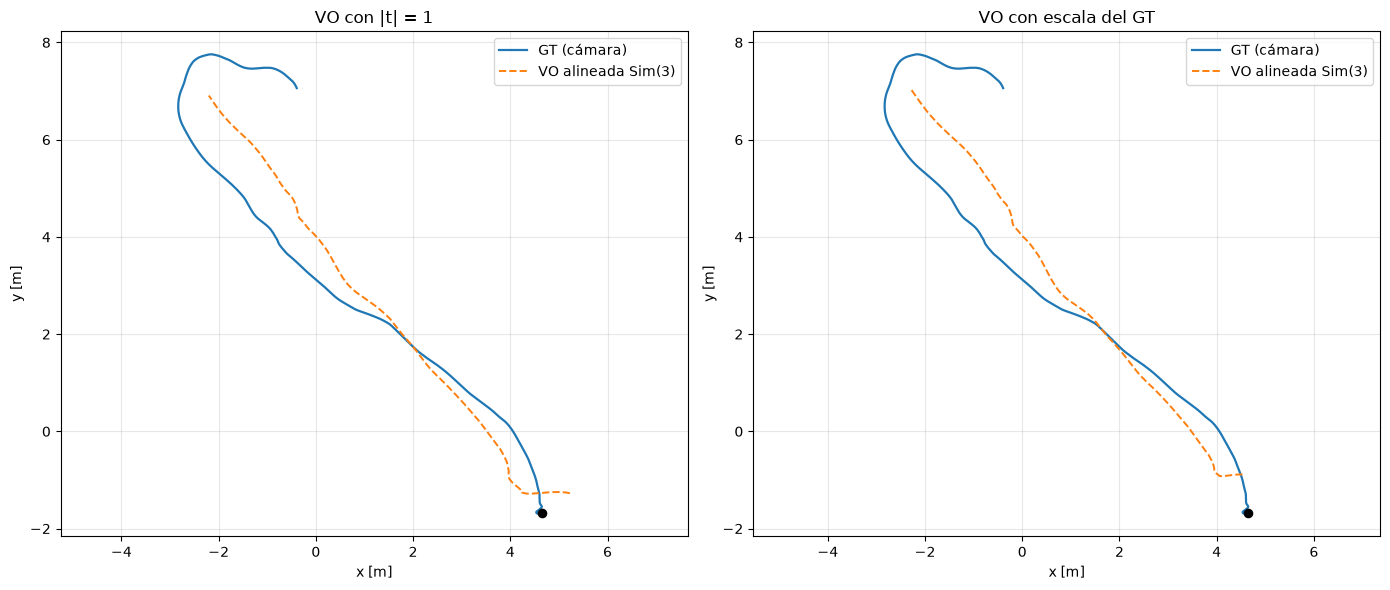

In [27]:
s, R_al, t_al = align_umeyama(p_gt, p_unit, True)
p_unit_al = (s * (R_al @ p_unit.T)).T + t_al
s2, R_al2, t_al2 = align_umeyama(p_gt, p_gtsc, True)
p_gtsc_al = (s2 * (R_al2 @ p_gtsc.T)).T + t_al2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (p_al, titulo) in zip(axes, [(p_unit_al, "VO con |t| = 1"),
                                     (p_gtsc_al, "VO con escala del GT")]):
    ax.plot(p_gt[:, 0], p_gt[:, 1], lw=1.6, label="GT (cámara)")
    ax.plot(p_al[:, 0], p_al[:, 1], lw=1.4, ls="--", label="VO alineada Sim(3)")
    ax.scatter(*p_gt[0, :2], c="k", s=35, zorder=5)
    ax.set_title(titulo); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.axis("equal"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

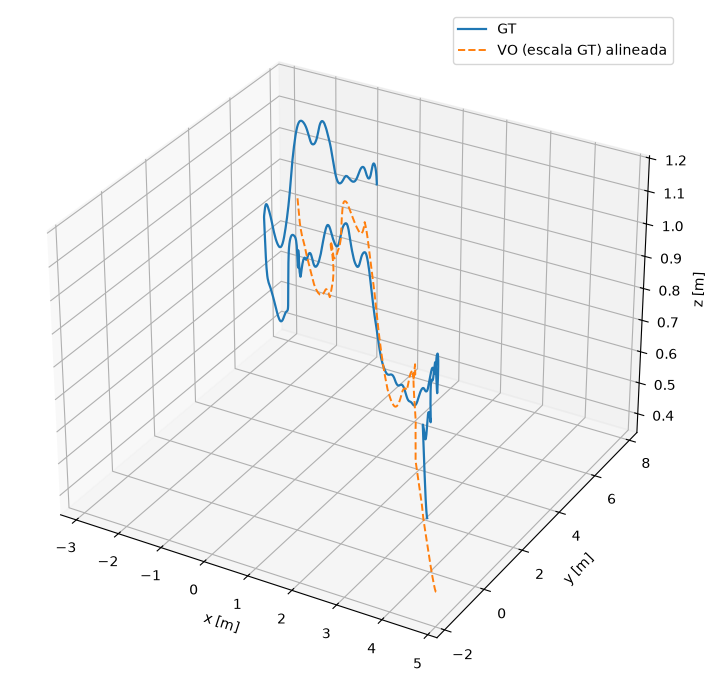

In [28]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
ax.plot(*p_gt.T, lw=1.6, label="GT")
ax.plot(*p_gtsc_al.T, lw=1.4, ls="--", label="VO (escala GT) alineada")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend(); plt.tight_layout(); plt.show()

In [39]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=p_gt[:, 0],
    y=p_gt[:, 1],
    z=p_gt[:, 2],
    mode="lines",
    name="GT",
    line=dict(width=5)
))

fig.add_trace(go.Scatter3d(
    x=p_gtsc_al[:, 0],
    y=p_gtsc_al[:, 1],
    z=p_gtsc_al[:, 2],
    mode="lines",
    name="VO (escala GT) alineada",
    line=dict(width=4, dash="dash")
))

fig.update_layout(
    title="Trayectoria 3D: GT vs VO",
    scene=dict(
        xaxis_title="x [m]",
        yaxis_title="y [m]",
        zaxis_title="z [m]",
        aspectmode="data"
    ),
    width=900,
    height=700
)

fig.show()

## 4.6 - De dónde viene la deriva

En orden de importancia:

1. **Deriva de escala.** Cada par de frames trae su propia escala y al componer no
   hay nada que las haga coherentes. Es el error dominante y es **irreparable en
   monocular puro**: no es un problema de implementación, es que la información no
   está en las imágenes. La IMU la aporta (Fase 5).

2. **Poco paralaje.** Ya lo cuantificaste en 4.4: por debajo de ~1 px de paralaje
   derrotada, la dirección de `t` es ruido. La IMU propaga durante esos tramos.

3. **Composición incremental.** Cada estimación tiene error y se acumula sin
   ningún mecanismo que lo corrija. Un back-end que reobserve features antiguas lo
   reduce (Fase 6).

La celda siguiente mide la primera, que es la que menos intuición suele tener.

desplazamiento real por frame: mediana 2.67 cm, p5 0.97 cm, p95 4.60 cm
  cociente p95/p5 = 4.7
  recorrido real = 16.08 m
  recorrido si todos los pasos midieran lo mismo = 15.99 m


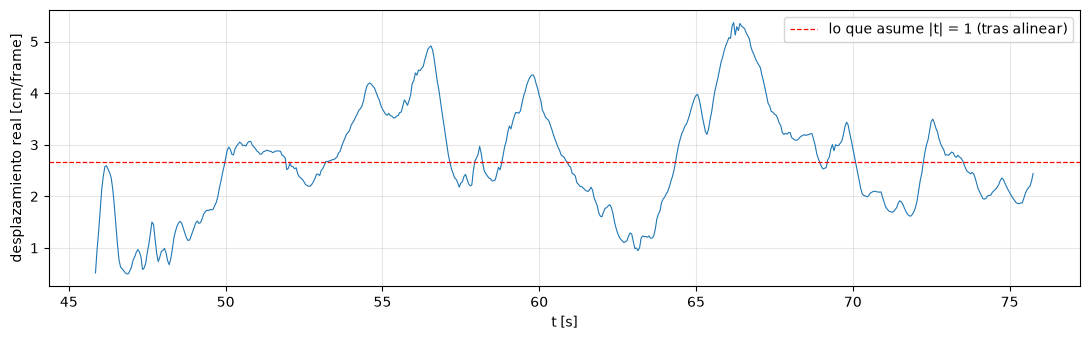

In [29]:
# Cuánto varía la escala verdadera dentro de la ventana: esa variación es
# exactamente lo que la composición con |t| = 1 no puede reproducir.
print(f"desplazamiento real por frame: mediana {np.median(escalas_gt)*100:.2f} cm, "
      f"p5 {np.percentile(escalas_gt, 5)*100:.2f} cm, p95 {np.percentile(escalas_gt, 95)*100:.2f} cm")
print(f"  cociente p95/p5 = {np.percentile(escalas_gt, 95)/max(np.percentile(escalas_gt, 5), 1e-9):.1f}")
print(f"  recorrido real = {escalas_gt.sum():.2f} m")
print(f"  recorrido si todos los pasos midieran lo mismo = {len(escalas_gt)*np.median(escalas_gt):.2f} m")

plt.figure(figsize=(11, 3.5))
plt.plot(t_cam_gt[K0:K1 - 1], escalas_gt * 100, lw=0.8)
plt.axhline(np.median(escalas_gt) * 100, color="r", ls="--", lw=0.9,
            label="lo que asume |t| = 1 (tras alinear)")
plt.ylabel("desplazamiento real [cm/frame]"); plt.xlabel("t [s]")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4.7 - Variante contra keyframe

En vez de estimar la pose entre frames consecutivos, se estima contra un
**keyframe** que solo se cambia cuando el paralaje supera un umbral. Dos ventajas:

- el paralaje es mayor, así que la dirección de `t` es mucho más fiable (lo viste
  en la gráfica de 4.4);
- se componen muchas menos poses, y la deriva de composición crece con el número
  de composiciones, no con el tiempo.

El precio: entre keyframes no hay pose nueva. Aquí se emite la pose relativa al
keyframe en cada frame, y solo se **compone** al promover uno nuevo.

In [30]:
PARALAJE_MIN_KF = 15.0        # px de paralaje derrotada para promover keyframe
MIN_COMUNES = 80


def ejecutar_vo_keyframe(k0, k1, escalar_con_gt=False):
    """VO contra keyframe. Devuelve (poses (N,4,4), indices, k_de_los_keyframes)."""
    tr = RastreadorKLT()
    T_wc_kf = np.eye(4)
    poses, indices, kfs = [], [], []

    kf_ids, kf_pts, kf_k = None, None, None
    for k in range(k0, k1):
        ids, p_prev, p_cur = tr.rastrear(leer(k), k)

        if kf_ids is None:                       # primer frame: es el keyframe
            kf_ids, kf_pts, kf_k = ids.copy(), p_cur.copy(), k
            kfs.append(k)
            poses.append(T_wc_kf.copy()); indices.append(k)
            continue

        comunes, i_kf, i_cur = np.intersect1d(kf_ids, ids, return_indices=True)
        if len(comunes) < MIN_COMUNES:
            # se han perdido demasiadas: hay que refrescar el keyframe aunque no
            # haya paralaje, o el track se queda sin correspondencias
            promover = True
            T_ckf = None
        else:
            n_kf = pixeles_a_normalizadas(kf_pts[i_kf])
            n_cu = pixeles_a_normalizadas(p_cur[i_cur])
            T_ckf, inl = pose_relativa(n_kf, n_cu)
            if T_ckf is None:
                promover = True
            else:
                par = np.median(paralaje_derotada(n_kf, n_cu, T_ckf[:3, :3]))
                promover = par > PARALAJE_MIN_KF

        if T_ckf is not None:
            T_kf_c = inv_T(T_ckf)                # del frame actual al keyframe
            if escalar_con_gt:
                n = np.linalg.norm(T_kf_c[:3, 3])
                real = np.linalg.norm((inv_T(T_world_cam[kf_k]) @ T_world_cam[k])[:3, 3])
                if n > 1e-9:
                    T_kf_c[:3, 3] *= real / n
            T_wc = T_wc_kf @ T_kf_c
        else:
            T_wc = T_wc_kf.copy()

        poses.append(T_wc.copy()); indices.append(k)

        if promover:
            T_wc_kf = T_wc.copy()
            kf_ids, kf_pts, kf_k = ids.copy(), p_cur.copy(), k
            kfs.append(k)

    return np.array(poses), np.array(indices), np.array(kfs)

In [31]:
poses_kf, idx_kf, kfs = ejecutar_vo_keyframe(K0, K1)
poses_kf_gt, _, _ = ejecutar_vo_keyframe(K0, K1, escalar_con_gt=True)
p_gt_kf = T_world_cam[idx_kf, :3, 3]

print(f"keyframes: {len(kfs)} de {K1-K0} frames "
      f"(1 cada {(K1-K0)/max(len(kfs),1):.1f} frames)")
print(f"keyframe, |t| = 1        : ATE Sim(3) = {ate_rmse(p_gt_kf, poses_kf[:, :3, 3], True):.3f} m")
print(f"keyframe, escala del GT  : ATE Sim(3) = {ate_rmse(p_gt_kf, poses_kf_gt[:, :3, 3], True):.3f} m")
print(f"frame a frame, |t| = 1   : ATE Sim(3) = {ate_rmse(p_gt, p_unit, True):.3f} m")
print(f"frame a frame, escala GT : ATE Sim(3) = {ate_rmse(p_gt, p_gtsc, True):.3f} m")

keyframes: 437 de 600 frames (1 cada 1.4 frames)
keyframe, |t| = 1        : ATE Sim(3) = 0.921 m
keyframe, escala del GT  : ATE Sim(3) = 0.851 m
frame a frame, |t| = 1   : ATE Sim(3) = 0.878 m
frame a frame, escala GT : ATE Sim(3) = 0.905 m


Compara las cuatro filas antes de sacar conclusiones. Lo esperable es que el
keyframe gane con escala del GT (menos composiciones, más paralaje) y que con
`|t| = 1` la mejora sea menor o incluso nula: al haber menos pasos y más largos, la
hipótesis implícita de "todos los pasos miden lo mismo" es aún más falsa, porque
los intervalos entre keyframes duran tiempos distintos.

O sea: el keyframe arregla el problema geométrico y **empeora** el problema de
escala. Los dos se arreglan a la vez solo cuando entra la IMU.

## 4.8 - Trampas

| Trampa | Efecto |
|---|---|
| Rectificar la imagen **y** pasar `dist` a `undistortPoints` | Distorsión aplicada dos veces; reproyecciones de 5–10 px |
| Rectificar con los mapas de la Fase 2 (a `K_new`) y normalizar con `K` | Escala falseada un 22 %; la profundidad triangulada sale mal |
| Confundir `T_c1_c0` con `T_c0_c1` al componer | La trayectoria sale hacia atrás |
| Umbral de RANSAC en píxeles con puntos normalizados | Todo inlier: E basura sin ningún aviso |
| Detectar degeneración con el flujo en vez del paralaje derrotado | Una rotación pura pasa el test y mete ruido puro |
| Redetectar sin máscara | Features duplicadas, E mal condicionada |
| Sin forward-backward check | 10–20 % de tracks corruptos |

Las tres primeras se comprueban con tests negativos: producen resultados **casi
razonables**, que es lo que las hace peligrosas.

In [32]:
# Test negativo 1: umbral de RANSAC en píxeles sobre puntos normalizados.
tr_neg = RastreadorKLT()
for k in range(K0, K0 + 40):
    ids, p_prev, p_cur = tr_neg.rastrear(leer(k), k)

n0 = pixeles_a_normalizadas(p_prev)
n1 = pixeles_a_normalizadas(p_cur)
i_ref = (K0 + 39) - 1

for thr, etiqueta in [(1.0 / F_MEDIA, "correcto: 1 px / focal"),
                      (1.0, "trampa: 1 px sin dividir")]:
    E, mask = cv2.findEssentialMat(n0, n1, np.eye(3), method=METODO, prob=0.999, threshold=thr)
    if E is None:
        print(f"{etiqueta:26s}: sin solución")
        continue
    n_in, R, t, _ = cv2.recoverPose(E[:3], n0, n1, np.eye(3), mask=mask.copy())
    T_c0c1 = inv_T(make_T(R, t.ravel()))
    t_gt_ref = T_rel_gt[i_ref][:3, 3]
    err_R = np.degrees(np.linalg.norm(Log(T_rel_gt[i_ref][:3, :3].T @ T_c0c1[:3, :3])))
    cos = (t_gt_ref @ T_c0c1[:3, 3]) / (np.linalg.norm(t_gt_ref) * np.linalg.norm(T_c0c1[:3, 3]) + 1e-12)
    print(f"{etiqueta:26s}: inliers {(mask.ravel() > 0).mean():.2f}   "
          f"err_R = {err_R:6.3f}°   err_dir = {np.degrees(np.arccos(np.clip(cos, -1, 1))):6.2f}°")

correcto: 1 px / focal    : inliers 0.99   err_R =  0.038°   err_dir =   2.05°
trampa: 1 px sin dividir  : inliers 1.00   err_R =  0.213°   err_dir =   6.61°


composición correcta : ATE Sim(3) = 0.905 m
composición invertida: ATE Sim(3) = 0.899 m


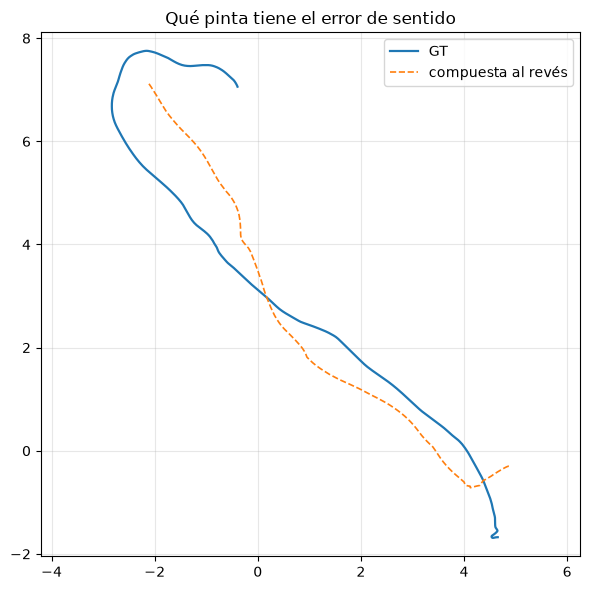

In [33]:
# Test negativo 2: componer con T_c1_c0 en vez de su inversa.
poses_mal = componer([inv_T(T) if T is not None else None for T in pasos], escalas_gt)
print(f"composición correcta : ATE Sim(3) = {ate_rmse(p_gt, poses_gtsc[:, :3, 3], True):.3f} m")
print(f"composición invertida: ATE Sim(3) = {ate_rmse(p_gt, poses_mal[:, :3, 3], True):.3f} m")

plt.figure(figsize=(6, 6))
s_m, R_m, t_m = align_umeyama(p_gt, poses_mal[:, :3, 3], True)
p_mal_al = (s_m * (R_m @ poses_mal[:, :3, 3].T)).T + t_m
plt.plot(p_gt[:, 0], p_gt[:, 1], lw=1.6, label="GT")
plt.plot(p_mal_al[:, 0], p_mal_al[:, 1], lw=1.2, ls="--", label="compuesta al revés")
plt.axis("equal"); plt.grid(alpha=0.3); plt.legend()
plt.title("Qué pinta tiene el error de sentido"); plt.tight_layout(); plt.show()

## 4.9 - Guardar

Además de la trayectoria se guarda la **tabla de features**: `(id, frame, u, v)`
en columnas. Es el formato que necesita el MSCKF de la Fase 6A para agrupar por
`id` y triangular cada feature con todas sus observaciones. Guardarlo ahora evita
volver a correr el tracker en cada iteración de aquella fase, que es lo que la
hace insufrible.

In [34]:
tr_id, tr_k, tr_u, tr_v = [], [], [], []
for i, hist in tr.tracks.items():
    for (kk, u, v) in hist:
        tr_id.append(i); tr_k.append(kk); tr_u.append(u); tr_v.append(v)
tr_id = np.array(tr_id, dtype=np.int64)
tr_k = np.array(tr_k, dtype=np.int32)
tr_u = np.array(tr_u, dtype=np.float32)
tr_v = np.array(tr_v, dtype=np.float32)
print(f"tabla de features: {len(tr_id)} observaciones de {len(np.unique(tr_id))} tracks")

tabla de features: 118030 observaciones de 1979 tracks


In [35]:
SALIDA.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    SALIDA,
    k0=K0, k1=K1, idx=idx, t=t_cam_gt[K0:K1],
    poses_unit=poses_unit, poses_gtsc=poses_gtsc,
    poses_kf=poses_kf, idx_kf=idx_kf, keyframes=kfs,
    err_rot=reg_rot, err_dir=reg_dir, paralaje=reg_par,
    inliers=reg_inl, n_pts=reg_n, flujo=reg_flujo,
    tr_id=tr_id, tr_k=tr_k, tr_u=tr_u, tr_v=tr_v,
    K=K, dist=dist, T_imu_cam=T_imu_cam,
)
print(f"Guardado en {SALIDA} ({SALIDA.stat().st_size / 1e6:.2f} MB)")

Guardado en C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase4_vo.npz (0.91 MB)


In [36]:
print("RESUMEN DE LA FASE 4")
print(f"  ventana                        : frames [{K0}, {K1}) = "
      f"[{t_cam_gt[K0]:.1f}, {t_cam_gt[K1-1]:.1f}] s")
print(f"  features/frame (mediana)       : {np.median(reg_n):.0f}")
print(f"  error de rotación relativa     : {np.median(reg_rot):.3f}° (mediana)")
print(f"  error de dirección de t        : {np.median(reg_dir):.2f}° (mediana)")
print(f"  ATE Sim(3), |t| = 1            : {ate_rmse(p_gt, p_unit, True):.3f} m   (criterio < 2 m)")
print(f"  ATE Sim(3), escala del GT      : {ate_rmse(p_gt, p_gtsc, True):.3f} m   <- cota del front-end")
print(f"  escala recuperada por Umeyama  : {align_umeyama(p_gt, p_unit, True)[0]:.4f}")

RESUMEN DE LA FASE 4
  ventana                        : frames [895, 1495) = [45.8, 75.8] s
  features/frame (mediana)       : 198
  error de rotación relativa     : 0.023° (mediana)
  error de dirección de t        : 2.44° (mediana)
  ATE Sim(3), |t| = 1            : 0.878 m   (criterio < 2 m)
  ATE Sim(3), escala del GT      : 0.905 m   <- cota del front-end
  escala recuperada por Umeyama  : 0.0871


## Test de aceptación de la Fase 4

**1.** `recoverPose` devuelve `t` con norma 1 siempre. ¿Qué información concreta
de la escena habría que añadir para fijar esa norma, y por qué dos imágenes de una
cámara monocular no pueden contenerla nunca, ni con resolución infinita?

**2.** El error de rotación relativa sale un orden de magnitud mejor que el de
dirección de la traslación. Explica por qué, en términos de cuántos puntos y qué
geometría restringen cada una.

**3.** En la gráfica de 4.4, el error de dirección se dispara por debajo de cierto
paralaje. Justifica el umbral que elegirías para `PARALAJE_MIN` y estima qué
fracción de los frames de MH_01 quedan por debajo.

**4.** La variante con keyframe mejora con la escala del GT pero no
necesariamente con `|t| = 1`. Explica por qué, y qué tendría que aportar la IMU
para que el keyframe ganara también en el caso monocular.

**5.** Con `desp_rel` de la Fase 2 y la escala que devuelve Umeyama, calcula qué
error de escala tendrías si aplicaras esa escala global a un tramo donde el dron
va al doble de la velocidad media. Ese número es el que la Fase 5 tiene que
eliminar.